# Linear Spin-Wave Theory: dari Hamiltonian sampai energi magnon

Notebook ini membangun linear spin-wave theory (LSWT) dari Hamiltonian mikroskopik sampai spektrum magnon dan peta spektral $Q$-$E$. Alur numeriknya mengikuti gagasan umum tutorial [pyLiSW](https://github.com/bingli621/pyLiSW): tentukan atom/sublattice, bond, lintasan momentum, hitung dispersi, lalu visualisasikan mode dan intensitasnya.

Perbedaannya: notebook ini **self-contained**. Implementasi hanya membutuhkan NumPy dan Matplotlib; paket `pyLiSW` tidak wajib dipasang.

Model yang diuji:

1. rantai feromagnet (FM) 1D;
2. FM dengan easy-axis anisotropy;
3. FM dengan Dzyaloshinskii-Moriya interaction (DMI);
4. rantai antiferomagnet (AF) dua sublattice.

Konvensi utama:

$$
H_J=-\sum_{\langle i,j\rangle}J_{ij}\,\mathbf S_i\cdot\mathbf S_j,
$$

sehingga $J>0$ berarti FM. Setiap *physical bond* disimpan tepat satu kali. Energi dinyatakan dalam meV dan $\hbar=1$ selama perhitungan.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)
OUTPUT_DIR = Path.cwd()

plt.rcParams.update({
    "figure.figsize": (8.0, 5.2),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 1. Hamiltonian magnetik umum

Hamiltonian yang digunakan adalah

$$
\boxed{
\begin{aligned}
H={}&-\sum_{\langle i,j\rangle}J_{ij}\,\mathbf S_i\cdot\mathbf S_j\\
&-\sum_iK_i(\widehat{\mathbf m}_i\cdot\mathbf S_i)^2\\
&+\sum_{\langle i,j\rangle}\mathbf D_{ij}\cdot(\mathbf S_i\times\mathbf S_j)\\
&-\sum_i\mathbf h_i\cdot\mathbf S_i.
\end{aligned}}
$$

Komponennya:

- $J_{ij}$: isotropic exchange;
- $K_i$ dan $\widehat{\mathbf m}_i$: besar dan arah single-ion anisotropy;
- $\mathbf D_{ij}$: vektor DMI;
- $\mathbf h_i=g_i\mu_B\mathbf B$: medan dalam satuan energi.

Seluruh coupling bilinear antar-situs digabungkan menjadi matriks $3\times3$:

$$
H_{\mathrm{bond}}=\sum_b\mathbf S_i^T\mathsf K_b\mathbf S_j,
$$

dengan

$$
\mathsf K_b=-J_bI_3+\Gamma_b+\mathsf K_b^{\mathrm{DM}},
$$

dan

$$
\boxed{
\mathsf K_b^{\mathrm{DM}}=
\begin{pmatrix}
0&D_z&-D_y\\
-D_z&0&D_x\\
D_y&-D_x&0
\end{pmatrix}.}
$$

Matriks tersebut memenuhi

$$
\mathbf S_i^T\mathsf K_b^{\mathrm{DM}}\mathbf S_j
=\mathbf D_{ij}\cdot(\mathbf S_i\times\mathbf S_j).
$$

## 2. Ground state klasik dan local frame

Arah spin klasik pada sublattice $r$ ditulis

$$
\mathbf S_r^{\mathrm{cl}}=S_r\widehat{\mathbf n}_r.
$$

LSWT harus diekspansikan terhadap konfigurasi *stationary*:

$$
\boxed{\mathbf S_r^{\mathrm{cl}}\times\mathbf H_r^{\mathrm{eff}}=0},
\qquad
\mathbf H_r^{\mathrm{eff}}=-\frac{\partial E_{\mathrm{cl}}}{\partial\mathbf S_r^{\mathrm{cl}}}.
$$

Untuk tiap sublattice dibangun matriks rotasi local-to-global $R_r$ dengan kolom

$$
R_r=(\widehat{\mathbf x}_r\;\widehat{\mathbf y}_r\;\widehat{\mathbf z}_r),
\qquad \widehat{\mathbf z}_r=\widehat{\mathbf n}_r.
$$

Hubungan operator spin:

$$
\boxed{\mathbf S_r=R_r\widetilde{\mathbf S}_r},
\qquad R_r^TR_r=I,
\qquad \det R_r=1.
$$

Untuk bond $r\to s$:

$$
\boxed{\mathsf M_b=R_r^T\mathsf K_bR_s},
$$

sehingga

$$
H_b=\widetilde{\mathbf S}_r^T\mathsf M_b\widetilde{\mathbf S}_s.
$$

Untuk isotropic exchange, $\mathsf K_b=-J_bI$ dan

$$
\mathsf M_b=-J_bR_r^TR_s=-J_bF(r,s).
$$

## 3. Holstein-Primakoff dan truncation LSWT

Pada koordinat lokal, spin klasik menunjuk sepanjang $+\widetilde z$. Transformasi Holstein-Primakoff linear adalah

$$
\boxed{
\widetilde S_r^z=S_r-a_r^\dagger a_r,
\qquad
\widetilde S_r^+=\sqrt{2S_r}\,a_r,
\qquad
\widetilde S_r^-=\sqrt{2S_r}\,a_r^\dagger.}
$$

Karena

$$
\widetilde S_r^x=\frac{\widetilde S_r^++\widetilde S_r^-}{2},
\qquad
\widetilde S_r^y=\frac{\widetilde S_r^+-\widetilde S_r^-}{2i},
$$

diperoleh

$$
\widetilde S_r^x=\sqrt{\frac{S_r}{2}}(a_r+a_r^\dagger),
$$

$$
\widetilde S_r^y=-i\sqrt{\frac{S_r}{2}}(a_r-a_r^\dagger).
$$

Hamiltonian kemudian diurutkan menurut jumlah operator boson:

$$
H=E_{\mathrm{cl}}+H_1+H_2+O(a^3).
$$

- $E_{\mathrm{cl}}$: energi klasik;
- $H_1$: linear residual, harus nol pada ground state stationary;
- $H_2$: Hamiltonian LSWT yang akan didiagonalisasi.

## 4. Ekspansi satu bond tanpa melewati koefisien

Tuliskan

$$
\mathsf M_b=
\begin{pmatrix}
M_{xx}&M_{xy}&M_{xz}\\
M_{yx}&M_{yy}&M_{yz}\\
M_{zx}&M_{zy}&M_{zz}
\end{pmatrix}.
$$

Definisikan

$$
c_r=\sqrt{\frac{S_r}{2}},
\qquad
c_s=\sqrt{\frac{S_s}{2}}.
$$

Setelah semua suku $xx,xy,yx,yy,zz$ dikumpulkan, normal hopping adalah

$$
\boxed{
T_b=c_rc_s\left[M_{xx}+M_{yy}+i(M_{yx}-M_{xy})\right].}
$$

Anomalous pairing adalah

$$
\boxed{
P_b=c_rc_s\left[M_{xx}-M_{yy}-i(M_{xy}+M_{yx})\right].}
$$

Hamiltonian kuadratik satu bond:

$$
\boxed{
\begin{aligned}
H_b^{(2)}={}&-M_{zz}S_s\,a_r^\dagger a_r-M_{zz}S_r\,a_s^\dagger a_s\\
&+T_ba_r^\dagger a_s+T_b^*a_s^\dagger a_r\\
&+P_ba_ra_s+P_b^*a_r^\dagger a_s^\dagger.
\end{aligned}}
$$

Linear residual dari bond yang sama:

$$
\lambda_r^{(b)}=c_rS_s(M_{xz}-iM_{yz}),
$$

$$
\lambda_s^{(b)}=c_sS_r(M_{zx}-iM_{zy}).
$$

Jumlah seluruh $\lambda_r$ harus nol sebelum spektrum dipercaya.

## 5. Kontribusi onsite

Untuk anisotropi

$$
H_{K,r}=-K_r(\widehat{\mathbf m}_r\cdot\mathbf S_r)^2,
$$

rotasikan sumbunya:

$$
\begin{pmatrix}A_x\\A_y\\A_z\end{pmatrix}
=R_r^T\widehat{\mathbf m}_r.
$$

Kontribusi ke normal block:

$$
\boxed{\mathsf A_{rr}^{K}=K_rS_r(2A_z^2-A_x^2-A_y^2).}
$$

Kontribusi ke creation-pair block:

$$
\boxed{\Delta_{rr}^{K}=-K_rS_r(A_x+iA_y)^2.}
$$

Untuk Zeeman term $H_Z=-\mathbf h_r\cdot\mathbf S_r$, definisikan $\mathbf b_r=R_r^T\mathbf h_r$. Kontribusi kuadratiknya hanya

$$
\boxed{\mathsf A_{rr}^{Z}=b_{rz}.}
$$

## 6. Fourier transform dan matriks bosonic BdG

Posisi situs adalah $\mathbf r_{\ell r}=\mathbf R_\ell+\boldsymbol\tau_r$. Gunakan

$$
a_{\ell r}=\frac1{\sqrt{N_c}}\sum_{\mathbf q}
e^{+i\mathbf q\cdot\mathbf r_{\ell r}}a_{\mathbf q r}.
$$

Untuk bond dengan displacement $\mathbf d_b$, normal hopping membawa fase $e^{+i\mathbf q\cdot\mathbf d_b}$, sedangkan annihilation pairing membawa fase $e^{-i\mathbf q\cdot\mathbf d_b}$.

Bentuk canonical momentum-space:

$$
H_2=\sum_{\mathbf q}\mathbf a_{\mathbf q}^\dagger\mathsf A(\mathbf q)\mathbf a_{\mathbf q}
+\frac12\sum_{\mathbf q}\left[
\mathbf a_{\mathbf q}^T\mathsf B(\mathbf q)\mathbf a_{-\mathbf q}
+\mathrm{h.c.}\right].
$$

Definisikan Nambu vector

$$
\Psi_{\mathbf q}=
\begin{pmatrix}
\mathbf a_{\mathbf q}\\
\mathbf a_{-\mathbf q}^\dagger
\end{pmatrix}.
$$

Hamiltonian BdG:

$$
\boxed{
H_2=\frac12\sum_{\mathbf q}\Psi_{\mathbf q}^\dagger
\mathcal H_{\mathrm{BdG}}(\mathbf q)\Psi_{\mathbf q}+C,}
$$

$$
\boxed{
\mathcal H_{\mathrm{BdG}}(\mathbf q)=
\begin{pmatrix}
\mathsf A(\mathbf q)&\Delta(\mathbf q)\\
\Delta^\dagger(\mathbf q)&\mathsf A^T(-\mathbf q)
\end{pmatrix}.}
$$

Notasi scan `Hamiltonian.pdf`, $H=V^\dagger LV$, berhubungan melalui

$$
\boxed{L(\mathbf q)=\frac12\mathcal H_{\mathrm{BdG}}(\mathbf q)}
$$

untuk basis dan penjumlahan full Brillouin zone yang sama, sampai konstanta normal-ordering.

## 7. Energi magnon: masalah eigenvalue bosonik

Karena Nambu vector mengandung annihilation dan creation operator, commutator metric bukan identity:

$$
\eta=
\begin{pmatrix}
I_M&0\\
0&-I_M
\end{pmatrix}.
$$

Energi magnon diperoleh dari

$$
\boxed{
\eta\mathcal H_{\mathrm{BdG}}(\mathbf q)t_n
=\varepsilon_n(\mathbf q)t_n.}
$$

Dalam notasi matriks $L$ pada scan:

$$
\boxed{2\eta L(\mathbf q)t_n=\varepsilon_n(\mathbf q)t_n.}
$$

Mode fisik dipilih dari eigenvalue real positif dengan bosonic norm positif,

$$
t_n^\dagger\eta t_n>0.
$$

In [2]:
@dataclass(frozen=True)
class Bond:
    r: int
    s: int
    displacement: np.ndarray
    coupling: np.ndarray
    label: str = ""


@dataclass
class LSWTModel:
    name: str
    spins: np.ndarray
    positions: np.ndarray
    directions: np.ndarray
    bonds: Sequence[Bond]
    anisotropy_K: np.ndarray
    anisotropy_axes: np.ndarray
    fields: np.ndarray

    @property
    def n_sublattices(self):
        return len(self.spins)


def unit(vector, tol=1e-14):
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)
    if norm < tol:
        raise ValueError("Zero vector cannot be normalized.")
    return vector / norm


def local_frame(direction):
    # Return a proper local-to-global rotation with local z along direction.
    z_axis = unit(direction)
    seeds = np.eye(3)
    seed = seeds[np.argmin(np.abs(seeds @ z_axis))]
    x_axis = unit(seed - np.dot(seed, z_axis) * z_axis)
    y_axis = unit(np.cross(z_axis, x_axis))
    rotation = np.column_stack((x_axis, y_axis, z_axis))
    if np.linalg.det(rotation) < 0:
        rotation[:, 1] *= -1
    return rotation


def dmi_matrix(D):
    Dx, Dy, Dz = np.asarray(D, dtype=float)
    return np.array([
        [0.0, Dz, -Dy],
        [-Dz, 0.0, Dx],
        [Dy, -Dx, 0.0],
    ])


def rotations(model):
    return np.stack([local_frame(n) for n in model.directions])

In [3]:
def bond_data(model, bond, frames=None):
    if frames is None:
        frames = rotations(model)
    r, s = bond.r, bond.s
    Sr, Ss = model.spins[r], model.spins[s]
    M = frames[r].T @ bond.coupling @ frames[s]
    prefactor = np.sqrt(Sr * Ss) / 2.0
    T = prefactor * (M[0, 0] + M[1, 1] + 1j * (M[1, 0] - M[0, 1]))
    P = prefactor * (M[0, 0] - M[1, 1] - 1j * (M[0, 1] + M[1, 0]))
    return M, T, P


def linear_residuals(model):
    Msub = model.n_sublattices
    frames = rotations(model)
    residual = np.zeros(Msub, dtype=complex)

    for bond in model.bonds:
        r, s = bond.r, bond.s
        Sr, Ss = model.spins[r], model.spins[s]
        M, _, _ = bond_data(model, bond, frames)
        residual[r] += np.sqrt(Sr / 2) * Ss * (M[0, 2] - 1j * M[1, 2])
        residual[s] += np.sqrt(Ss / 2) * Sr * (M[2, 0] - 1j * M[2, 1])

    for r in range(Msub):
        S = model.spins[r]
        axis_local = frames[r].T @ unit(model.anisotropy_axes[r])
        Ax, Ay, Az = axis_local
        K = model.anisotropy_K[r]
        residual[r] += -2 * K * Az * S * np.sqrt(S / 2) * (Ax - 1j * Ay)

        field_local = frames[r].T @ model.fields[r]
        bx, by, _ = field_local
        residual[r] += -np.sqrt(S / 2) * (bx - 1j * by)

    return residual


def blocks_at_q(model, q_vector):
    q_vector = np.asarray(q_vector, dtype=float)
    Msub = model.n_sublattices
    frames = rotations(model)
    A = np.zeros((Msub, Msub), dtype=complex)
    Delta = np.zeros((Msub, Msub), dtype=complex)

    for bond in model.bonds:
        r, s = bond.r, bond.s
        Sr, Ss = model.spins[r], model.spins[s]
        M, T, P = bond_data(model, bond, frames)
        phase = np.exp(1j * np.dot(q_vector, bond.displacement))

        A[r, r] += -M[2, 2] * Ss
        A[s, s] += -M[2, 2] * Sr
        A[r, s] += T * phase
        A[s, r] += np.conj(T * phase)

        Delta[r, s] += np.conj(P) * phase
        Delta[s, r] += np.conj(P) * np.conj(phase)

    for r in range(Msub):
        S = model.spins[r]
        axis_local = frames[r].T @ unit(model.anisotropy_axes[r])
        Ax, Ay, Az = axis_local
        K = model.anisotropy_K[r]
        A[r, r] += K * S * (2 * Az**2 - Ax**2 - Ay**2)
        Delta[r, r] += -K * S * (Ax + 1j * Ay) ** 2

        field_local = frames[r].T @ model.fields[r]
        A[r, r] += field_local[2]

    return A, Delta


def bdg_matrix(model, q_vector):
    q_vector = np.asarray(q_vector, dtype=float)
    A_q, Delta_q = blocks_at_q(model, q_vector)
    A_minus_q, _ = blocks_at_q(model, -q_vector)
    return np.block([
        [A_q, Delta_q],
        [Delta_q.conj().T, A_minus_q.T],
    ])

In [4]:
def magnon_modes(model, q_vector, tol=1e-8):
    Hbdg = bdg_matrix(model, q_vector)
    Msub = model.n_sublattices
    eta = np.diag(np.r_[np.ones(Msub), -np.ones(Msub)])
    dynamic = eta @ Hbdg
    eigenvalues, eigenvectors = np.linalg.eig(dynamic)

    modes = []
    for value, vector in zip(eigenvalues, eigenvectors.T):
        if abs(value.imag) > 1e-6:
            continue
        norm = np.real(np.vdot(vector, eta @ vector))
        if value.real > tol and norm > tol:
            vector = vector / np.sqrt(norm)
            modes.append((float(value.real), vector))

    modes.sort(key=lambda item: item[0])
    energies = [energy for energy, _ in modes[:Msub]]
    vectors = [vector for _, vector in modes[:Msub]]

    # Goldstone points can have zero eta-norm numerically. Preserve the
    # expected number of physical branches by padding them with zero.
    while len(energies) < Msub:
        energies.insert(0, 0.0)
        vectors.insert(0, np.zeros(2 * Msub, dtype=complex))

    return np.asarray(energies), np.asarray(vectors), Hbdg


def dispersion(model, q_vectors):
    energies = []
    for q in q_vectors:
        e, _, _ = magnon_modes(model, q)
        energies.append(e)
    return np.asarray(energies)


def matrix_diagnostics(model, q_vectors):
    hermiticity = []
    pairing = []
    for q in q_vectors:
        H = bdg_matrix(model, q)
        hermiticity.append(np.max(np.abs(H - H.conj().T)))
        _, Dq = blocks_at_q(model, q)
        _, Dminus = blocks_at_q(model, -np.asarray(q))
        pairing.append(np.max(np.abs(Dq.T - Dminus)))
    return max(hermiticity), max(pairing)

## 8. Definisi model

Rantai FM memakai satu sublattice dan satu bond $i\to i+1$. Dengan konvensi notebook,

$$
\mathsf K_b=-JI+\mathsf K^{\mathrm{DM}}(D_z).
$$

Rantai AF memakai dua sublattice dalam magnetic unit cell:

$$
\widehat{\mathbf n}_A=+\widehat z,
\qquad
\widehat{\mathbf n}_B=-\widehat z.
$$

Karena Hamiltonian dasarnya ditulis $-J\mathbf S_i\cdot\mathbf S_j$, AF dengan besar coupling $J_{\mathrm{AF}}>0$ dimasukkan sebagai matriks $+J_{\mathrm{AF}}I$.

In [5]:
def make_fm_chain(J=1.0, S=2.0, K=0.0, Dz=0.0, field=0.0, name="FM chain"):
    coupling = -J * np.eye(3) + dmi_matrix([0.0, 0.0, Dz])
    return LSWTModel(
        name=name,
        spins=np.array([S]),
        positions=np.array([[0.0, 0.0, 0.0]]),
        directions=np.array([[0.0, 0.0, 1.0]]),
        bonds=[Bond(0, 0, np.array([1.0, 0.0, 0.0]), coupling, "nearest")],
        anisotropy_K=np.array([K]),
        anisotropy_axes=np.array([[0.0, 0.0, 1.0]]),
        fields=np.array([[0.0, 0.0, field]]),
    )


def make_af_chain(Jaf=1.0, S=2.0, K=0.05, name="AF chain"):
    coupling = Jaf * np.eye(3)
    return LSWTModel(
        name=name,
        spins=np.array([S, S]),
        positions=np.array([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0]]),
        directions=np.array([[0.0, 0.0, 1.0], [0.0, 0.0, -1.0]]),
        bonds=[
            Bond(0, 1, np.array([1.0, 0.0, 0.0]), coupling, "A(n)-B(n)"),
            Bond(1, 0, np.array([1.0, 0.0, 0.0]), coupling, "B(n)-A(n+1)"),
        ],
        anisotropy_K=np.array([K, K]),
        anisotropy_axes=np.array([[0.0, 0.0, 1.0], [0.0, 0.0, 1.0]]),
        fields=np.zeros((2, 3)),
    )


fm = make_fm_chain(J=1.0, S=2.0, name="FM isotropic")
fm_easy = make_fm_chain(J=1.0, S=2.0, K=0.12, name="FM + easy axis")
fm_dmi = make_fm_chain(J=1.0, S=2.0, K=0.12, Dz=0.22, name="FM + easy axis + DMI")
af = make_af_chain(Jaf=1.0, S=2.0, K=0.05, name="AF two-sublattice")

for model in [fm, fm_easy, fm_dmi, af]:
    print(f"{model.name:28s} | linear residual = {np.max(np.abs(linear_residuals(model))):.3e}")

FM isotropic                 | linear residual = 0.000e+00
FM + easy axis               | linear residual = 0.000e+00
FM + easy axis + DMI         | linear residual = 0.000e+00
AF two-sublattice            | linear residual = 0.000e+00


## 9. Benchmark analitik

Untuk FM 1D dengan satu bond per cell:

$$
\boxed{
\varepsilon_{\mathrm{FM}}(q)
=2JS(1-\cos q)+2KS+h+2D_zS\sin q.}
$$

- $D_z=K=h=0$: Goldstone mode pada $q=0$;
- $K>0$: gap $2KS$;
- $D_z\neq0$: $\varepsilon(q)\neq\varepsilon(-q)$.

Untuk AF dua-sublattice dengan easy-axis $K$:

$$
A=2J_{\mathrm{AF}}S+2KS,
\qquad
B(q)=2J_{\mathrm{AF}}S\cos q,
$$

$$
\boxed{
\varepsilon_{\mathrm{AF}}(q)=\sqrt{A^2-B(q)^2}.}
$$

Pada $K=0$:

$$
\varepsilon_{\mathrm{AF}}(q)=2J_{\mathrm{AF}}S|\sin q|.
$$

In [6]:
# FM path: three reciprocal-lattice periods, mirroring pyLiSW tutorials.
H_rlu = np.linspace(0.0, 3.0, 901)
q_fm = np.column_stack((2 * np.pi * H_rlu, np.zeros_like(H_rlu), np.zeros_like(H_rlu)))

e_fm = dispersion(fm, q_fm)[:, 0]
e_easy = dispersion(fm_easy, q_fm)[:, 0]
e_dmi = dispersion(fm_dmi, q_fm)[:, 0]

J, S = 1.0, 2.0
q_scalar = q_fm[:, 0]
e_fm_exact = 2 * J * S * (1 - np.cos(q_scalar))
e_easy_exact = e_fm_exact + 2 * 0.12 * S
e_dmi_exact = e_easy_exact + 2 * 0.22 * S * np.sin(q_scalar)

# AF path restricted to the magnetic Brillouin zone.
H_af = np.linspace(-0.25, 0.25, 501)
q_af = np.column_stack((2 * np.pi * H_af, np.zeros_like(H_af), np.zeros_like(H_af)))
e_af = dispersion(af, q_af)
A_af = 2 * 1.0 * 2.0 + 2 * 0.05 * 2.0
B_af = 2 * 1.0 * 2.0 * np.cos(q_af[:, 0])
e_af_exact = np.sqrt(np.maximum(A_af**2 - B_af**2, 0.0))

print("Maximum FM analytic error      :", np.max(np.abs(e_fm - e_fm_exact)))
print("Maximum easy-axis error        :", np.max(np.abs(e_easy - e_easy_exact)))
print("Maximum FM+DMI analytic error  :", np.max(np.abs(e_dmi - e_dmi_exact)))
print("Maximum AF analytic error       :", np.max(np.abs(e_af[:, -1] - e_af_exact)))

assert np.max(np.abs(e_fm - e_fm_exact)) < 1e-8
assert np.max(np.abs(e_easy - e_easy_exact)) < 1e-8
assert np.max(np.abs(e_dmi - e_dmi_exact)) < 1e-8
assert np.max(np.abs(e_af[:, -1] - e_af_exact)) < 1e-7

Maximum FM analytic error      : 8.881784197001252e-16
Maximum easy-axis error        : 1.7763568394002505e-15
Maximum FM+DMI analytic error  : 1.7763568394002505e-15
Maximum AF analytic error       : 4.440892098500626e-15


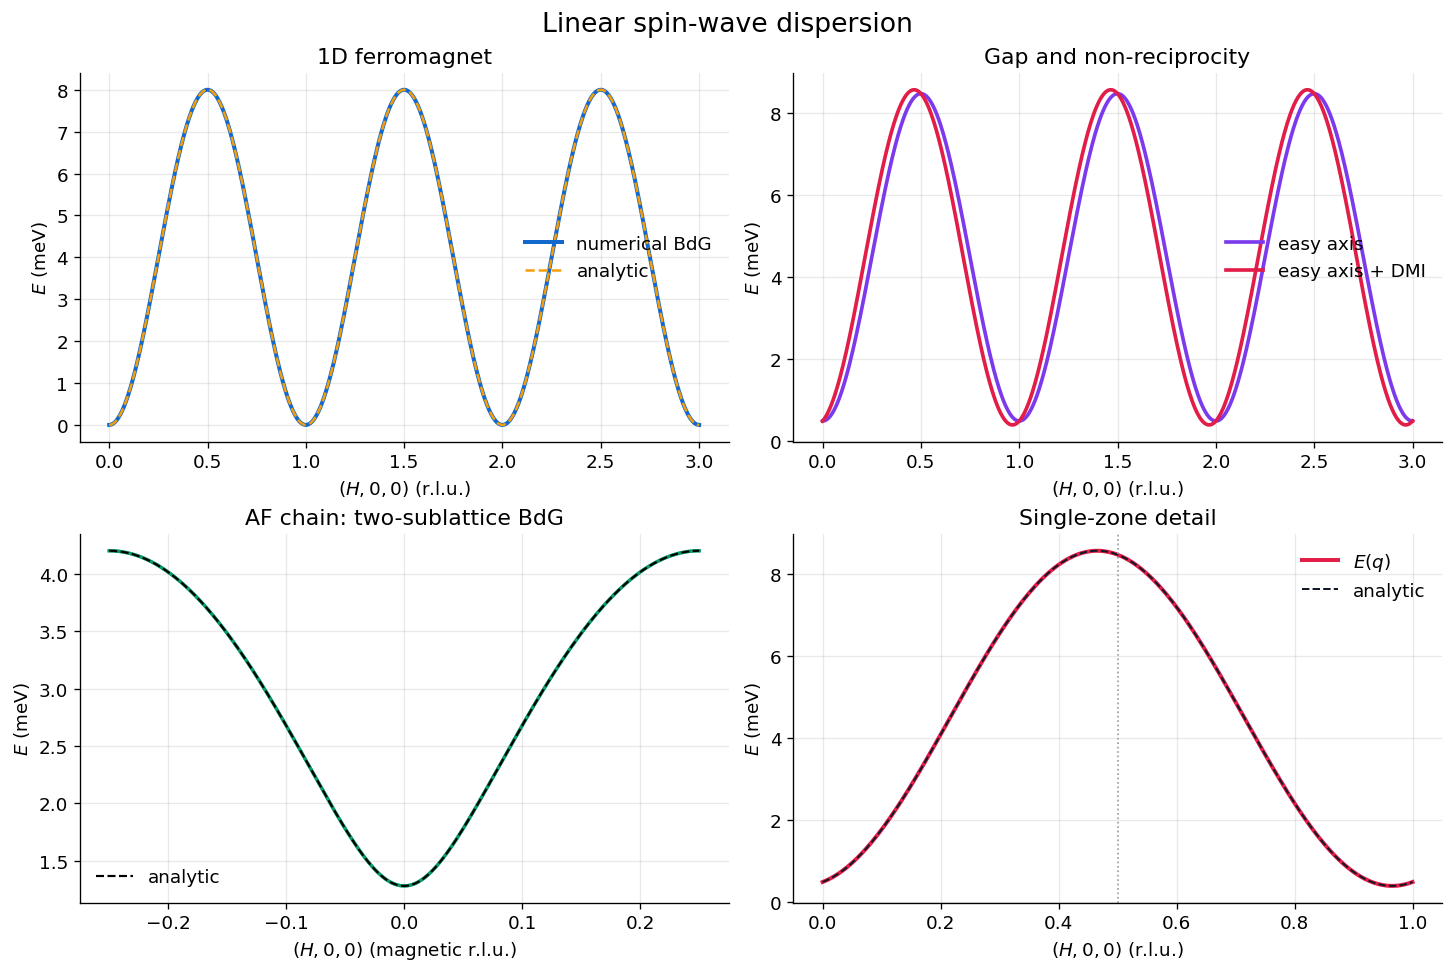

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

ax = axes[0, 0]
ax.plot(H_rlu, e_fm, color="#1368ce", lw=2.4, label="numerical BdG")
ax.plot(H_rlu, e_fm_exact, "--", color="#f59e0b", lw=1.5, label="analytic")
ax.set(title="1D ferromagnet", xlabel=r"$(H,0,0)$ (r.l.u.)", ylabel=r"$E$ (meV)")
ax.legend(frameon=False)

ax = axes[0, 1]
ax.plot(H_rlu, e_easy, color="#7c3aed", lw=2.2, label="easy axis")
ax.plot(H_rlu, e_dmi, color="#e11d48", lw=2.2, label="easy axis + DMI")
ax.set(title="Gap and non-reciprocity", xlabel=r"$(H,0,0)$ (r.l.u.)", ylabel=r"$E$ (meV)")
ax.legend(frameon=False)

ax = axes[1, 0]
for branch in range(e_af.shape[1]):
    ax.plot(H_af, e_af[:, branch], color="#059669", lw=2.0, alpha=0.85)
ax.plot(H_af, e_af_exact, "--", color="black", lw=1.3, label="analytic")
ax.set(title="AF chain: two-sublattice BdG", xlabel=r"$(H,0,0)$ (magnetic r.l.u.)", ylabel=r"$E$ (meV)")
ax.legend(frameon=False)

ax = axes[1, 1]
zone = (H_rlu >= 0.0) & (H_rlu <= 1.0)
ax.plot(H_rlu[zone], e_dmi[zone], color="#e11d48", lw=2.4, label=r"$E(q)$")
ax.plot(H_rlu[zone], e_dmi_exact[zone], "--", color="#111827", lw=1.2, label="analytic")
ax.axvline(0.5, color="0.6", lw=1, ls=":")
ax.set(title="Single-zone detail", xlabel=r"$(H,0,0)$ (r.l.u.)", ylabel=r"$E$ (meV)")
ax.legend(frameon=False)

fig.suptitle("Linear spin-wave dispersion", fontsize=16)
fig.savefig(OUTPUT_DIR / "spinwave_dispersion.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Peta spektral bergaya pyLiSW

`pyLiSW` dapat menghitung intensitas inelastic neutron scattering dengan faktor bentuk ion, polarization factor, thermal population, eigenvector, dan resolusi instrumen. Untuk menjaga notebook ini self-contained, peta berikut menggunakan representasi pedagogis

$$
I(Q,E)=\sum_nW_n(Q)
\exp\left[-\frac{(E-\varepsilon_n(Q))^2}{2\sigma_E^2}\right].
$$

$W_n(Q)$ di bawah hanya merupakan form-factor envelope sederhana. Jadi peta ini cocok untuk memeriksa lokasi cabang magnon dan gaya visual $Q$-$E$, tetapi **belum boleh dipakai sebagai prediksi absolut cross section neutron**.

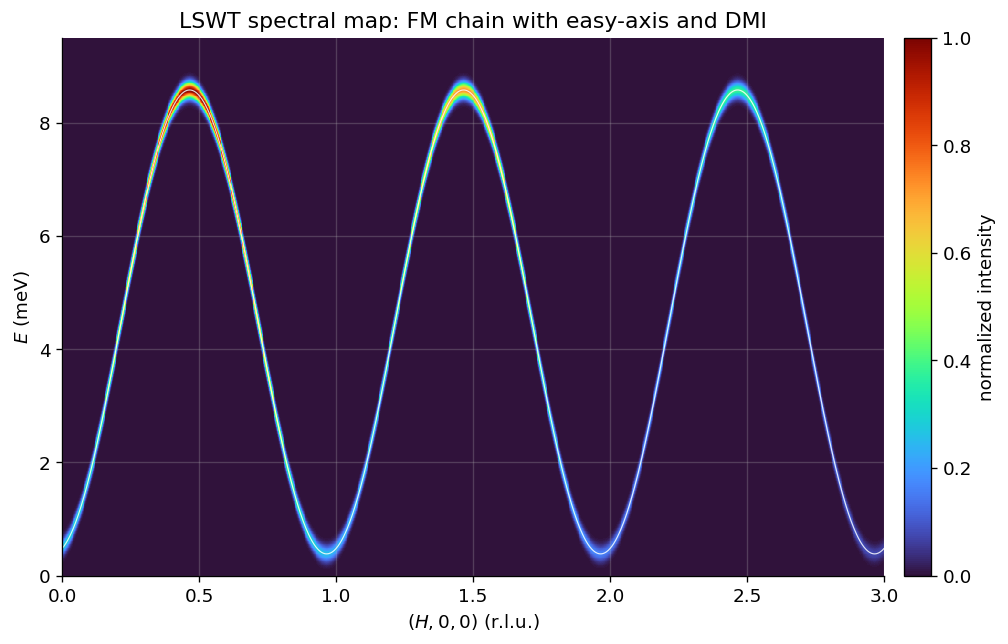

In [8]:
def gaussian_spectral_map(q_coordinate, energies, energy_axis, sigma=0.10, weights=None):
    energies = np.atleast_2d(energies)
    if energies.shape[0] != len(q_coordinate):
        energies = energies.T
    if weights is None:
        weights = np.ones_like(energies)
    intensity = np.zeros((len(energy_axis), len(q_coordinate)), dtype=float)
    for branch in range(energies.shape[1]):
        center = energies[:, branch][None, :]
        line = np.exp(-0.5 * ((energy_axis[:, None] - center) / sigma) ** 2)
        intensity += line * weights[:, branch][None, :]
    return intensity


energy_axis = np.linspace(0.0, 9.5, 700)
form_factor = np.exp(-0.16 * H_rlu**2)
structure_weight = 0.28 + 0.72 * np.sin(np.pi * H_rlu) ** 2
weights = (form_factor * structure_weight)[:, None]
intensity = gaussian_spectral_map(H_rlu, e_dmi[:, None], energy_axis, sigma=0.095, weights=weights)
intensity /= intensity.max()

fig, ax = plt.subplots(figsize=(9.0, 5.5))
mesh = ax.pcolormesh(H_rlu, energy_axis, intensity, shading="auto", cmap="turbo", vmin=0, vmax=1)
ax.plot(H_rlu, e_dmi, color="white", lw=0.7, alpha=0.85)
ax.set(
    title="LSWT spectral map: FM chain with easy-axis and DMI",
    xlabel=r"$(H,0,0)$ (r.l.u.)",
    ylabel=r"$E$ (meV)",
    xlim=(0, 3),
    ylim=(0, 9.5),
)
colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
colorbar.set_label("normalized intensity")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "spinwave_spectral_map.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Pemeriksaan numerik wajib

Sebelum memakai lattice atau spin texture yang lebih rumit, periksa:

1. $R_r^TR_r=I$ dan $\det R_r=1$;
2. linear residual $\lambda_r\simeq0$;
3. $\mathcal H_{\mathrm{BdG}}=\mathcal H_{\mathrm{BdG}}^\dagger$;
4. $\Delta(\mathbf q)^T=\Delta(-\mathbf q)$;
5. tidak ada eigenvalue kompleks untuk konfigurasi stabil;
6. benchmark FM, easy-axis, DMI, dan AF cocok dengan rumus analitik.

In [9]:
test_q = [
    np.array([0.13, 0.0, 0.0]),
    np.array([0.71, 0.0, 0.0]),
    np.array([1.37, 0.0, 0.0]),
]

for model in [fm, fm_easy, fm_dmi, af]:
    frame_errors = []
    determinant_errors = []
    for R in rotations(model):
        frame_errors.append(np.max(np.abs(R.T @ R - np.eye(3))))
        determinant_errors.append(abs(np.linalg.det(R) - 1.0))
    herm_error, pair_error = matrix_diagnostics(model, test_q)
    linear_error = np.max(np.abs(linear_residuals(model)))
    print(
        f"{model.name:28s} | "
        f"R^T R {max(frame_errors):.1e} | det {max(determinant_errors):.1e} | "
        f"H=H† {herm_error:.1e} | pairing {pair_error:.1e} | H1 {linear_error:.1e}"
    )
    assert max(frame_errors) < 1e-12
    assert max(determinant_errors) < 1e-12
    assert herm_error < 1e-10
    assert pair_error < 1e-10
    assert linear_error < 1e-10

FM isotropic                 | R^T R 0.0e+00 | det 0.0e+00 | H=H† 0.0e+00 | pairing 0.0e+00 | H1 0.0e+00
FM + easy axis               | R^T R 0.0e+00 | det 0.0e+00 | H=H† 0.0e+00 | pairing 0.0e+00 | H1 0.0e+00
FM + easy axis + DMI         | R^T R 0.0e+00 | det 0.0e+00 | H=H† 0.0e+00 | pairing 0.0e+00 | H1 0.0e+00
AF two-sublattice            | R^T R 0.0e+00 | det 0.0e+00 | H=H† 0.0e+00 | pairing 0.0e+00 | H1 0.0e+00


## 12. Mengganti parameter

Parameter yang paling mudah diubah berada pada pemanggilan:

```python
make_fm_chain(J=1.0, S=2.0, K=0.12, Dz=0.22, field=0.0)
make_af_chain(Jaf=1.0, S=2.0, K=0.05)
```

Untuk lattice umum:

1. masukkan satu arah klasik untuk setiap sublattice;
2. masukkan setiap physical bond satu kali;
3. tentukan displacement dan coupling matrix global;
4. jalankan `linear_residuals(model)`;
5. jalankan `dispersion(model, q_vectors)`;
6. baru tambahkan perhitungan neutron intensity yang lengkap.

Ringkasan teori-ke-kode:

$$
\boxed{
\mathsf K_b
\xrightarrow{R_r^T(\cdot)R_s}
\mathsf M_b
\xrightarrow{\mathrm{HP}}
T_b,P_b,M_{zz}
\xrightarrow{\mathrm{Fourier}}
\mathsf A(\mathbf q),\Delta(\mathbf q)
\xrightarrow{\eta\mathcal H_{\mathrm{BdG}}}
\varepsilon_n(\mathbf q).}
$$

Referensi implementasi dan gaya visual: [bingli621/pyLiSW](https://github.com/bingli621/pyLiSW). Sumber derivasi utama notebook ini adalah `Hamiltonian.pdf` yang menyusun exchange, anisotropy, DMI, medan, dan bentuk akhir $V^\dagger LV$.